In [ ]:
##Imports and Paths

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parent

regime_path = project_root / "processed_data" / "market_regime.csv"

regime = pd.read_csv(
    regime_path,
    parse_dates=["date"]
)

regime.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/harsha/Desktop/digital-currencies-2/processed_dataset/market_regime.csv'

In [ ]:
##Basic Checks
print("Shape:", regime.shape)
print("\nDate range:")
print(regime["date"].min(), "to", regime["date"].max())

print("\nMissing values:")
print(regime.isna().sum())

print("\nRegime counts:")
print(regime["regime"].value_counts())

print("\nRegime percentages:")
print(
    regime["regime"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Shape: (681, 27)

Date range:
2022-02-19 00:00:00 to 2023-12-31 00:00:00

Missing values:
date                0
btc_close           0
btc_return          0
btc_sma20           0
btc_sma50           0
btc_rsi14           0
btc_adx14           0
btc_volatility20    0
btc_sma_bearish     0
btc_rsi_bearish     0
eth_close           0
eth_return          0
eth_sma20           0
eth_sma50           0
eth_rsi14           0
eth_adx14           0
eth_volatility20    0
eth_sma_bearish     0
eth_rsi_bearish     0
fear_greed          0
fear_greed_label    0
fear_signal         0
btc_bearish         0
eth_bearish         0
stress_score        0
stress              0
regime              0
dtype: int64

Regime counts:
regime
normal      456
stressed    225
Name: count, dtype: int64

Regime percentages:
regime
normal      66.96
stressed    33.04
Name: proportion, dtype: float64


In [ ]:
## Stress-score distribution

print(regime["stress_score"].value_counts().sort_index())

print(
    regime.groupby("stress_score")[
        ["btc_return", "eth_return", "fear_greed"]
    ].mean()
)

stress_score
0    278
1    178
2     98
3    127
Name: count, dtype: int64
              btc_return  eth_return  fear_greed
stress_score                                    
0               0.002949    0.002521   58.431655
1               0.004288    0.006771   32.376404
2              -0.005297   -0.006804   32.540816
3              -0.005785   -0.007890   20.803150


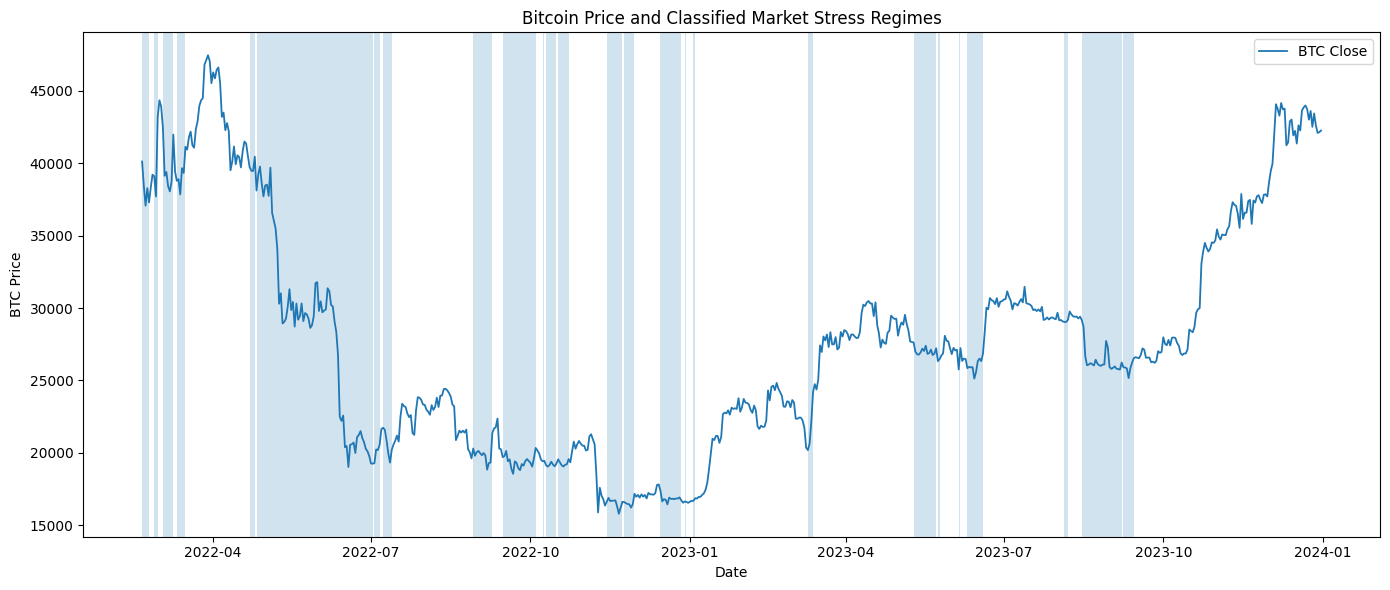

In [ ]:
## Full-sample BTC price with stressed regimes shaded

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    regime["date"],
    regime["btc_close"],
    linewidth=1.3,
    label="BTC Close"
)

stress = regime["stress"] == 1

start = None

for i in range(len(regime)):
    if stress.iloc[i] and start is None:
        start = regime["date"].iloc[i]

    if start is not None:
        is_last = i == len(regime) - 1
        stress_ended = not stress.iloc[i]

        if stress_ended or is_last:
            end = regime["date"].iloc[i]

            ax.axvspan(
                start,
                end,
                alpha=0.2
            )

            start = None

ax.set_title("Bitcoin Price and Classified Market Stress Regimes")
ax.set_xlabel("Date")
ax.set_ylabel("BTC Price")
ax.legend()

plt.tight_layout()
plt.show()

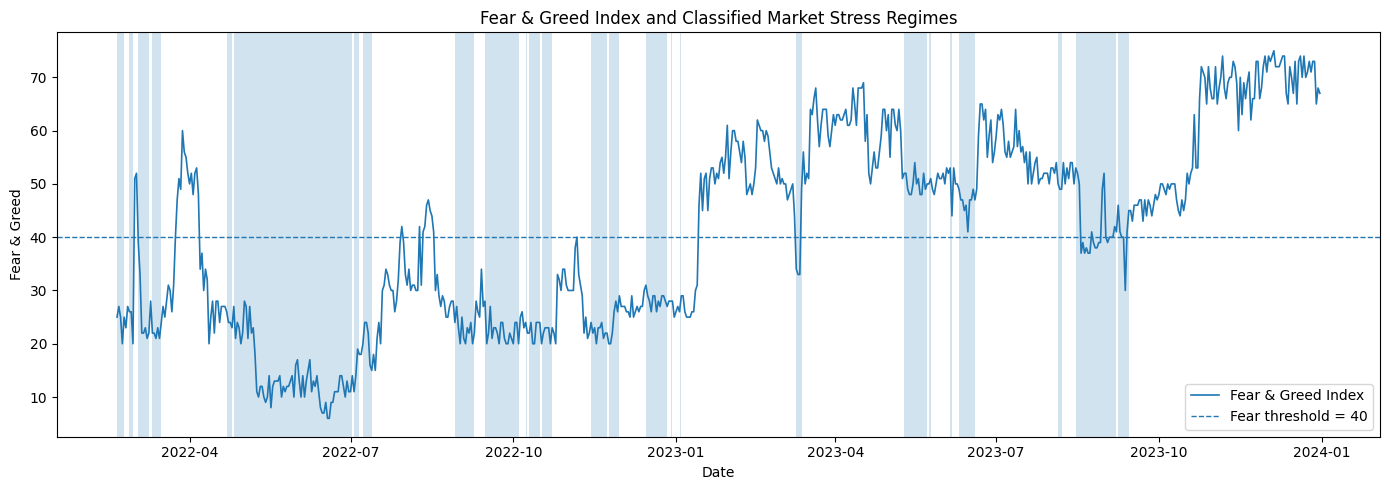

In [ ]:
## Fear & Greed with stress shading

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    regime["date"],
    regime["fear_greed"],
    linewidth=1.2,
    label="Fear & Greed Index"
)

ax.axhline(
    40,
    linestyle="--",
    linewidth=1,
    label="Fear threshold = 40"
)

stress = regime["stress"] == 1
start = None

for i in range(len(regime)):
    if stress.iloc[i] and start is None:
        start = regime["date"].iloc[i]

    if start is not None:
        is_last = i == len(regime) - 1
        stress_ended = not stress.iloc[i]

        if stress_ended or is_last:
            end = regime["date"].iloc[i]

            ax.axvspan(
                start,
                end,
                alpha=0.2
            )

            start = None

ax.set_title("Fear & Greed Index and Classified Market Stress Regimes")
ax.set_xlabel("Date")
ax.set_ylabel("Fear & Greed")
ax.legend()

plt.tight_layout()
plt.show()

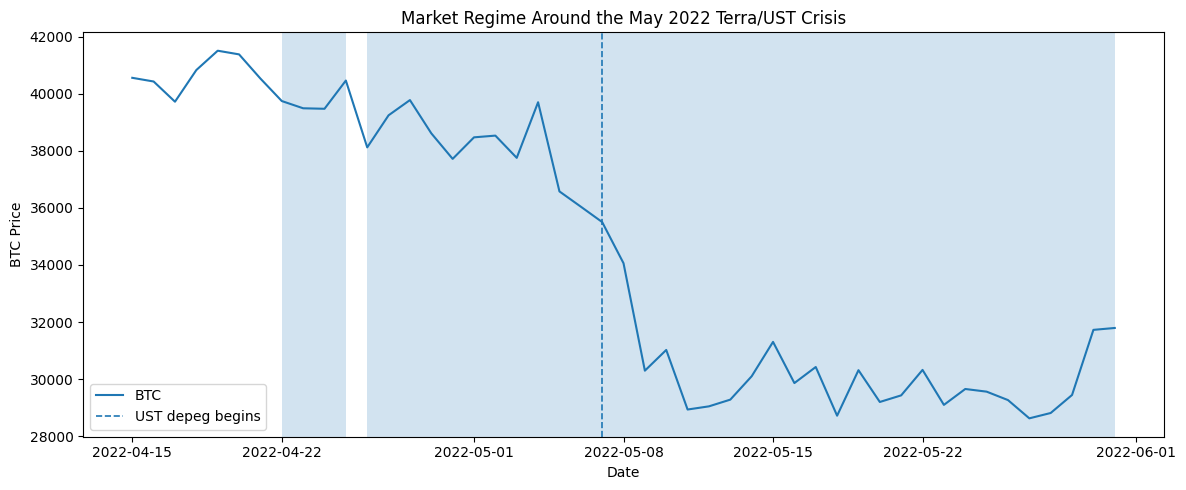

In [ ]:
## Terra crisis window

terra = regime[
    (regime["date"] >= "2022-04-15")
    & (regime["date"] <= "2022-05-31")
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    terra["date"],
    terra["btc_close"],
    linewidth=1.5,
    label="BTC"
)

stress = terra["stress"] == 1
start = None

for i in range(len(terra)):
    if stress.iloc[i] and start is None:
        start = terra["date"].iloc[i]

    if start is not None:
        is_last = i == len(terra) - 1
        stress_ended = not stress.iloc[i]

        if stress_ended or is_last:
            end = terra["date"].iloc[i]
            ax.axvspan(start, end, alpha=0.2)
            start = None

ax.axvline(
    pd.Timestamp("2022-05-07"),
    linestyle="--",
    linewidth=1.2,
    label="UST depeg begins"
)

ax.set_title("Market Regime Around the May 2022 Terra/UST Crisis")
ax.set_xlabel("Date")
ax.set_ylabel("BTC Price")
ax.legend()

plt.tight_layout()
plt.show()

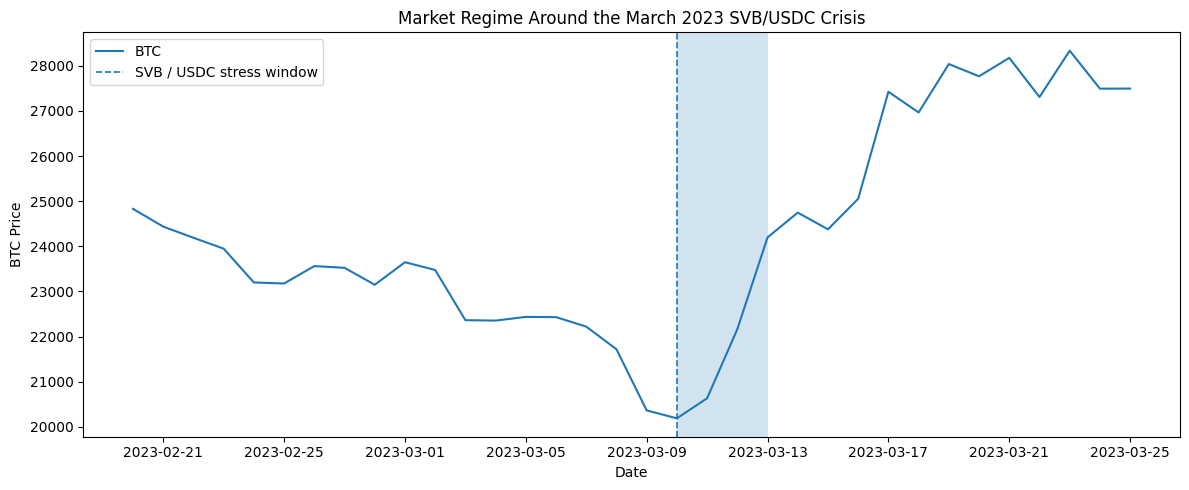

In [ ]:
## SVB / USDC crisis window

svb = regime[
    (regime["date"] >= "2023-02-20")
    & (regime["date"] <= "2023-03-25")
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    svb["date"],
    svb["btc_close"],
    linewidth=1.5,
    label="BTC"
)

stress = svb["stress"] == 1
start = None

for i in range(len(svb)):
    if stress.iloc[i] and start is None:
        start = svb["date"].iloc[i]

    if start is not None:
        is_last = i == len(svb) - 1
        stress_ended = not stress.iloc[i]

        if stress_ended or is_last:
            end = svb["date"].iloc[i]
            ax.axvspan(start, end, alpha=0.2)
            start = None

ax.axvline(
    pd.Timestamp("2023-03-10"),
    linestyle="--",
    linewidth=1.2,
    label="SVB / USDC stress window"
)

ax.set_title("Market Regime Around the March 2023 SVB/USDC Crisis")
ax.set_xlabel("Date")
ax.set_ylabel("BTC Price")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
## Descriptive statistics by regime

summary = (
    regime.groupby("regime")
    .agg(
        btc_mean_return=("btc_return", "mean"),
        btc_volatility=("btc_return", "std"),
        eth_mean_return=("eth_return", "mean"),
        eth_volatility=("eth_return", "std"),
        avg_fear_greed=("fear_greed", "mean"),
        avg_btc_adx=("btc_adx14", "mean"),
        avg_eth_adx=("eth_adx14", "mean"),
        observations=("date", "count")
    )
)

summary

,btc_mean_return,btc_volatility,eth_mean_return,eth_volatility,avg_fear_greed,avg_btc_adx,avg_eth_adx,observations
regime,,,,,,,,
normal,0.003472,0.027452,0.004180,0.033999,48.260965,38.447301,36.596874,456
stressed,-0.005573,0.029283,-0.007417,0.038013,25.915556,37.491673,41.561583,225


In [ ]:
## Regime duration analysis

regime["regime_change"] = (
    regime["regime"] != regime["regime"].shift()
).astype(int)

regime["regime_block"] = regime["regime_change"].cumsum()

durations = (
    regime.groupby(
        ["regime_block", "regime"]
    )
    .agg(
        start=("date", "min"),
        end=("date", "max"),
        duration_days=("date", "count")
    )
    .reset_index()
)

durations.head(20)

,regime_block,regime,start,end,duration_days
0,1,stressed,2022-02-19,2022-02-22,4
1,2,normal,2022-02-23,2022-02-25,3
2,3,stressed,2022-02-26,2022-02-27,2
3,4,normal,2022-02-28,2022-03-02,3
4,5,stressed,2022-03-03,2022-03-08,6
5,6,normal,2022-03-09,2022-03-10,2
6,7,stressed,2022-03-11,2022-03-15,5
7,8,normal,2022-03-16,2022-04-21,37
8,9,stressed,2022-04-22,2022-04-24,3
9,10,normal,2022-04-25,2022-04-25,1


In [ ]:
##Key crisis windows

terra_check = regime[
    (regime["date"] >= "2022-05-01")
    & (regime["date"] <= "2022-05-15")
][
    [
        "date",
        "stress_score",
        "regime",
        "fear_greed",
        "btc_adx14",
        "eth_adx14"
    ]
]

svb_check = regime[
    (regime["date"] >= "2023-03-01")
    & (regime["date"] <= "2023-03-20")
][
    [
        "date",
        "stress_score",
        "regime",
        "fear_greed",
        "btc_adx14",
        "eth_adx14"
    ]
]

print("TERRA WINDOW")
display(terra_check)

print("\nSVB / USDC WINDOW")
display(svb_check)

TERRA WINDOW


,date,stress_score,regime,fear_greed,btc_adx14,eth_adx14
71,2022-05-01,3,stressed,22,44.076354,43.300239
72,2022-05-02,3,stressed,28,41.746256,41.511618
73,2022-05-03,3,stressed,27,41.220868,41.683752
74,2022-05-04,3,stressed,21,41.204717,42.540613
75,2022-05-05,3,stressed,27,41.385160,42.832192
76,2022-05-06,3,stressed,22,41.353038,42.766989
77,2022-05-07,3,stressed,23,41.598208,42.804464
78,2022-05-08,3,stressed,18,41.440798,42.733618
79,2022-05-09,3,stressed,11,43.169575,44.070196
80,2022-05-10,3,stressed,10,44.544299,45.347003



SVB / USDC WINDOW


,date,stress_score,regime,fear_greed,btc_adx14,eth_adx14
375,2023-03-01,0,normal,50,29.627665,15.407644
376,2023-03-02,0,normal,51,29.112197,15.910043
377,2023-03-03,0,normal,50,29.718267,17.578723
378,2023-03-04,0,normal,50,30.339531,19.529799
379,2023-03-05,0,normal,47,30.160413,20.864315
380,2023-03-06,0,normal,48,29.945922,22.203360
381,2023-03-07,0,normal,49,30.424167,24.092932
382,2023-03-08,0,normal,50,31.498722,25.710180
383,2023-03-09,0,normal,44,32.450639,27.744568
384,2023-03-10,3,stressed,34,34.121010,30.119371
